In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_parquet("lightcurve_thindisk_fixed.parquet")

In [4]:
df

,ID,time,band,mag,cos_inc,log_mbh,log_mdot,redshift,transfer_function
0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[18.601379312883825, 18.478988056714947, 18.33...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.047684014704487, 18.905823595471603, 18.74...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
2,2,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[20.512323315781057, 20.366547224927594, 20.20...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
3,3,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.780730914621515, 19.636836610051976, 19.47...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
4,4,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.738476921842793, 19.617747513065655, 19.47...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
...,...,...,...,...,...,...,...,...,...
95,95,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[18.97423810788804, 18.81720760616239, 18.6342...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
96,96,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.1330954272589, 18.991627425400257, 18.8438...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
97,97,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.023543956009597, 18.8827998371771, 18.7176...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."
98,98,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.952300007584594, 19.831175541663416, 19.69...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326..."


## plot light curves

In [5]:
def plot_lc(time, mag, band, magerr=None):
    unique_band, cnts = np.unique(band, return_counts=True)

    time_by_band = np.zeros((len(unique_band), max(cnts)))
    mag_by_band = np.zeros((len(unique_band), max(cnts)))
    magerr_by_band = np.zeros((len(unique_band), max(cnts)))

    for ib, b in enumerate(unique_band):
        ind = np.where(band == b)[0]
        time_by_band[ib, : len(ind)] = time[ind]
        mag_by_band[ib, : len(ind)] = mag[ind]
        if magerr != None:
            magerr_by_band[ib, : len(ind)] = magerr[ind]

    plt.figure(figsize=(10, 5))
    for i in range(time_by_band.shape[0]):
        plt.errorbar(time_by_band[i], mag_by_band[i], yerr=magerr_by_band[i], ls="-")

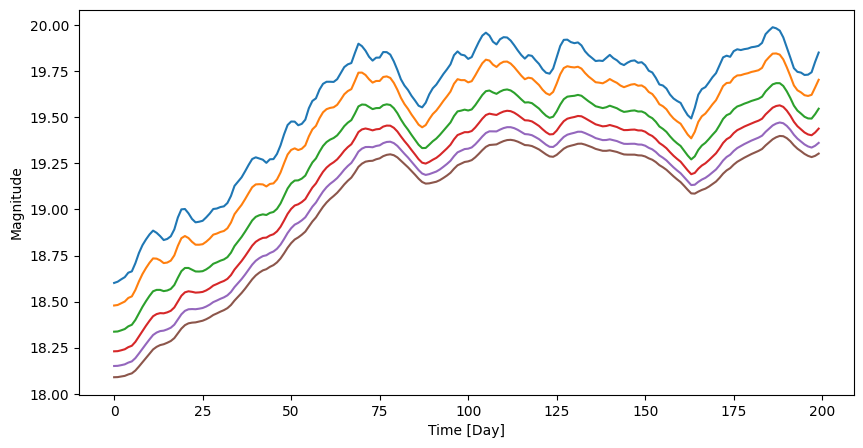

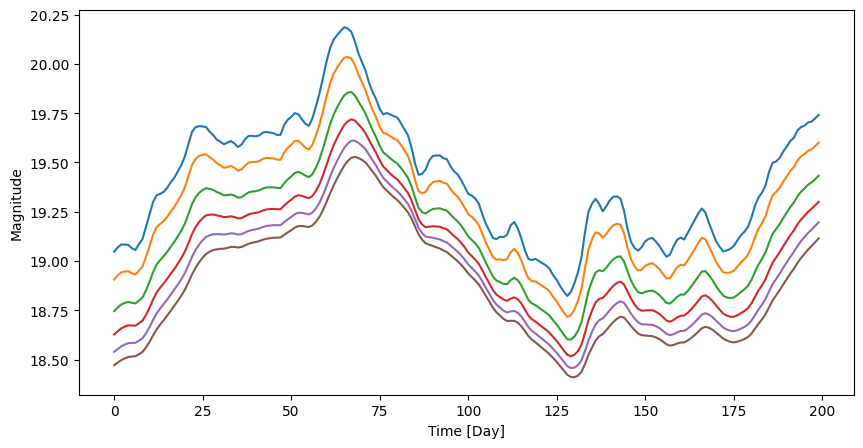

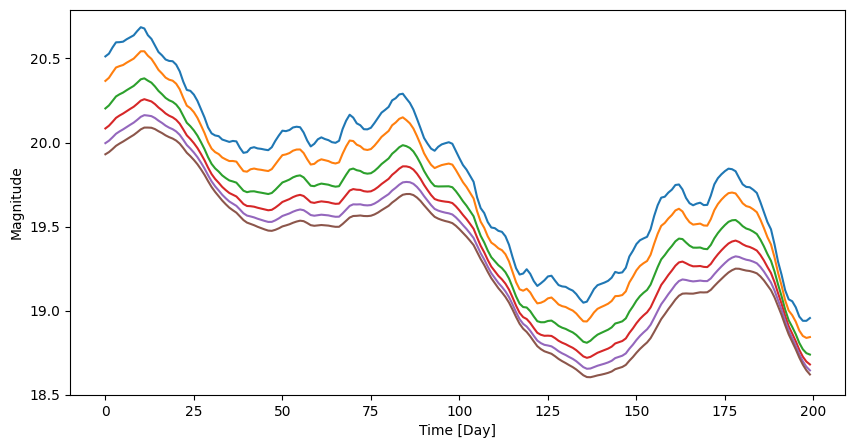

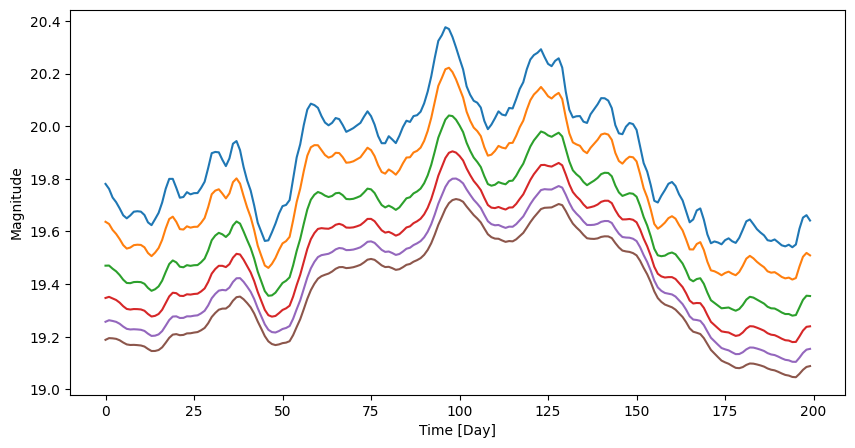

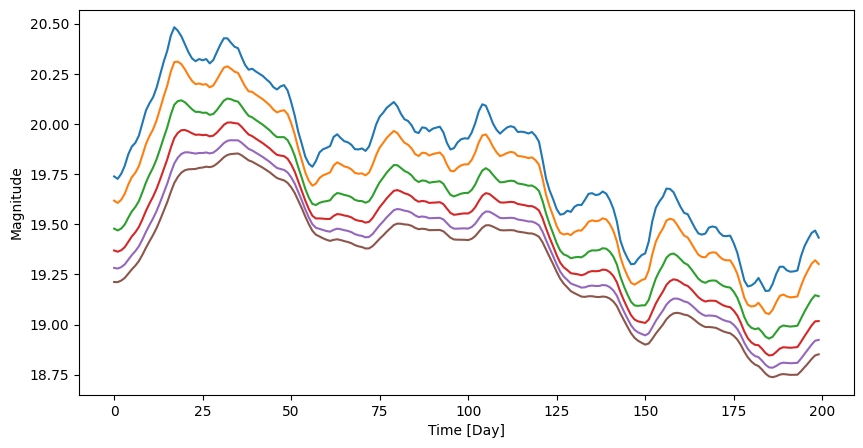

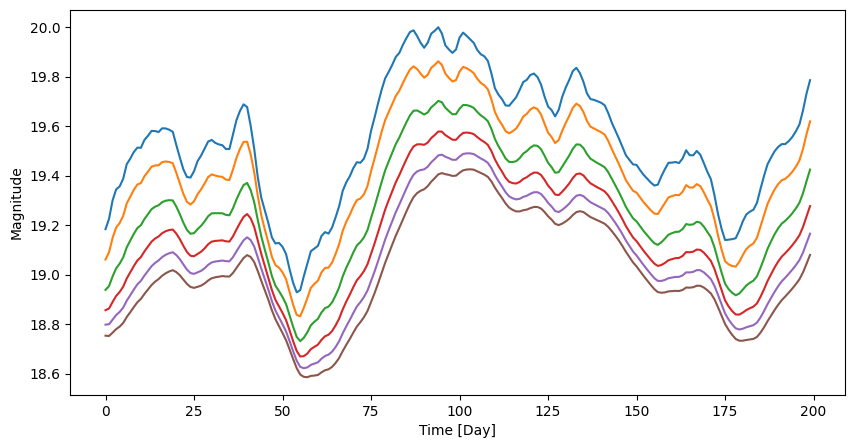

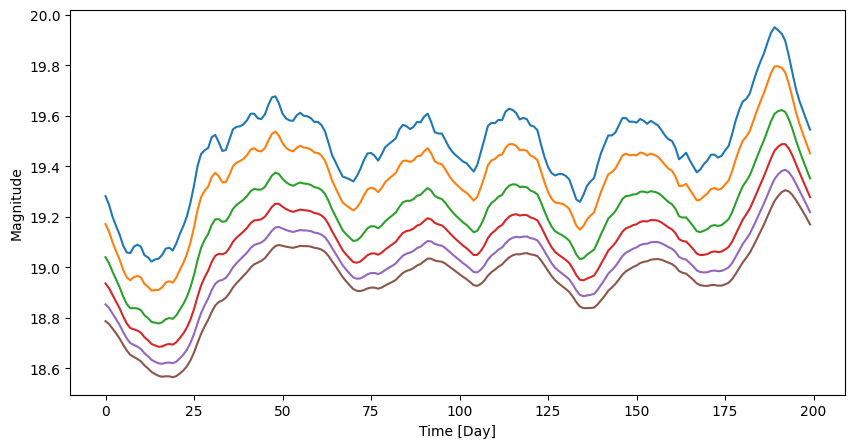

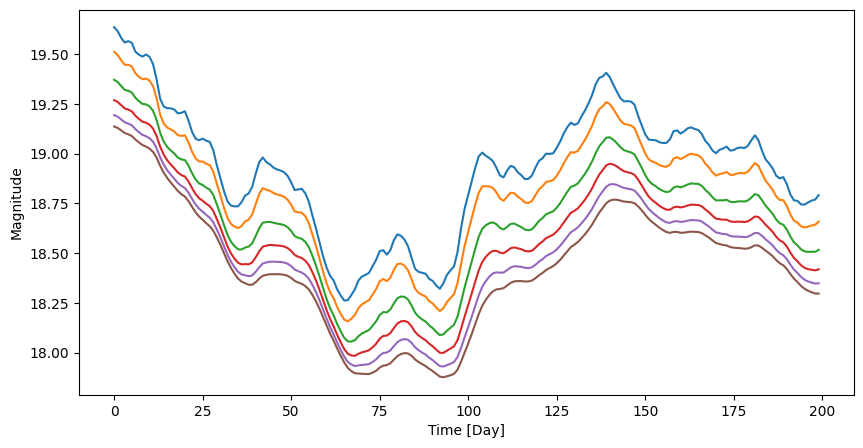

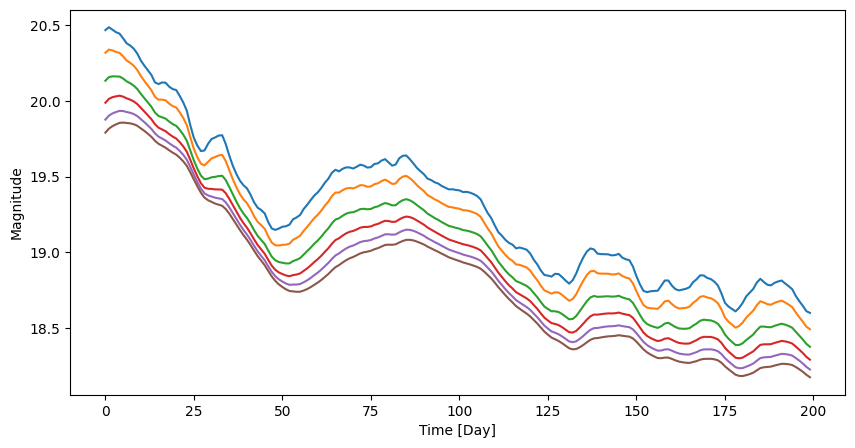

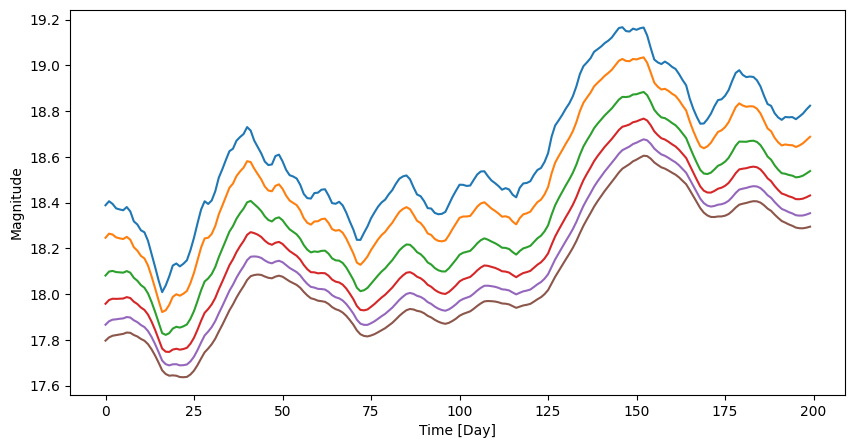

In [7]:
for idx in range(10):
    plot_lc(df["time"][idx], df["mag"][idx], df["band"][idx], magerr=None)
    plt.xlabel("Time [Day]")
    plt.ylabel("Magnitude")

## plot transfer function & get lags

2.1842446730521603
2.973574177527805
4.200837845368423
5.364424911008781
6.361364586737727
7.18104368469921


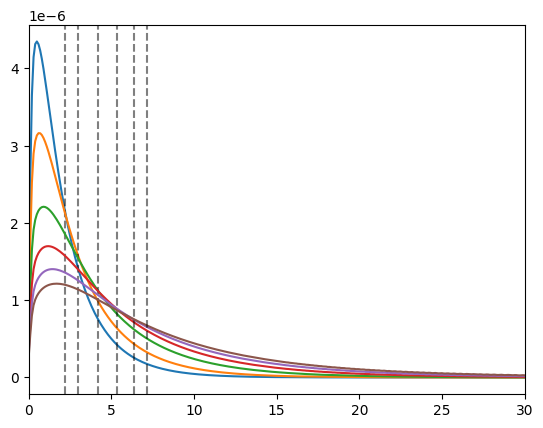

In [8]:
idx = 0
for idx in range(1):
    for j in range(6):
        tau = df["transfer_function"][idx].reshape(301, 7).T[0]
        tf = df["transfer_function"][idx].reshape(301, 7).T[j + 1]
        lag = np.trapz(tf * tau, x=tau) / np.trapz(tf, x=tau)
        print(lag)

        plt.plot(tau, tf, "-")
        plt.axvline(lag, ls="--", c="k", alpha=0.5)
        plt.xlim(0, 30)

In [9]:
all_lags = []
for idx in range(len(df)):
    lags = []
    for j in range(6):
        tau = df["transfer_function"][idx].reshape(301, 7).T[0]
        tf = df["transfer_function"][idx].reshape(301, 7).T[j + 1]
        lags.append(np.trapz(tf * tau, x=tau) / np.trapz(tf, x=tau))
    all_lags.append(lags)
df["lag"] = all_lags

## LSDB format

In [46]:
!pip install lsdb

In [12]:
import nested_pandas as npd

In [13]:
df

,ID,time,band,mag,cos_inc,log_mbh,log_mdot,redshift,transfer_function,lag
0,0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[18.601379312883825, 18.478988056714947, 18.33...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326...","[2.1842446730521603, 2.973574177527805, 4.2008..."
1,1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.047684014704487, 18.905823595471603, 18.74...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326...","[2.1842446730521603, 2.973574177527805, 4.2008..."
...,...,...,...,...,...,...,...,...,...,...
98,98,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.952300007584594, 19.831175541663416, 19.69...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326...","[2.1842446730521603, 2.973574177527805, 4.2008..."
99,99,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, ...","[0, 1, 2, 3, 4, 5, 0, 1, 2, 3, 4, 5, 0, 1, 2, ...","[19.70704383178405, 19.558780709784052, 19.378...",0.866,8.0,0.0,0.1,"[0.0, 1.139046864493016e-06, 7.766344777047326...","[2.1842446730521603, 2.973574177527805, 4.2008..."


In [14]:
df_nf = npd.NestedFrame(df)

In [15]:
df_nf = df_nf.nest_lists(columns=["time", "band", "mag"], name="light_curve")

In [16]:
df_nf

ID  cos_inc  log_mbh  log_mdot  redshift  \
0    0    0.866      8.0       0.0       0.1   
1    1    0.866      8.0       0.0       0.1   
..  ..      ...      ...       ...       ...   
98  98    0.866      8.0       0.0       0.1   
99  99    0.866      8.0       0.0       0.1   

                                    transfer_function  \
0   [0.0, 1.139046864493016e-06, 7.766344777047326...   
1   [0.0, 1.139046864493016e-06, 7.766344777047326...   
..                                                ...   
98  [0.0, 1.139046864493016e-06, 7.766344777047326...   
99  [0.0, 1.139046864493016e-06, 7.766344777047326...   

                                                  lag  \
0   [2.1842446730521603, 2.973574177527805, 4.2008...   
1   [2.1842446730521603, 2.973574177527805, 4.2008...   
..                                                ...   
98  [2.1842446730521603, 2.973574177527805, 4.2008...   
99  [2.1842446730521603, 2.973574177527805, 4.2008...   

                                          light_curve  
0   [{time: 0.0, band: 0, mag: 18.601379}; …] (120...  
1   [{time: 0.0, band: 0, mag: 19.047684}; …] (120...  
..                                                ...  
98  [{time: 0.0, band: 0, mag: 19.9523}; …] (1200 ...  
99  [{time: 0.0, band: 0, mag: 19.707044}; …] (120...  

[100 rows x 8 columns]

In [17]:
df_nf.to_parquet("lightcurve_thindisk_fixed_nested.parquet")